In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

from sklearn.metrics import accuracy_score

In [2]:
x_train = np.linspace(-1, 1, 20)

In [3]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [4]:
x_test = np.linspace(-1, 1, 20)

In [5]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

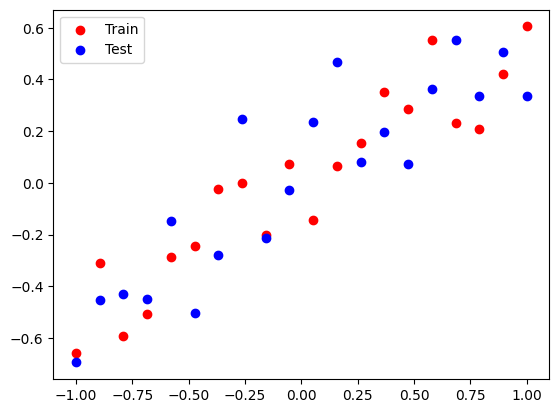

In [6]:
plt.scatter(x_train, y_train, c = "Red", label = "Train")
plt.scatter(x_test, y_test, c= "Blue", label = "Test")

plt.legend()
plt.show()

In [7]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=1))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [10]:
history = model.fit(x_train, y_train, epochs=100, validation_data = (x_test, y_test))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1369 - val_loss: 0.1207
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.1081 - val_loss: 0.0972
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - loss: 0.0847 - val_loss: 0.0784
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - loss: 0.0661 - val_loss: 0.0636
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 0.0514 - val_loss: 0.0518
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - loss: 0.0399 - val_loss: 0.0430
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - loss: 0.0312 - val_loss: 0.0368
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0252 - val_loss: 0.0327
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0212 - val_loss: 0.0304
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0191 - val_loss: 0.0296
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 0.0185 - val_loss: 0.0299
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0189

In [11]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


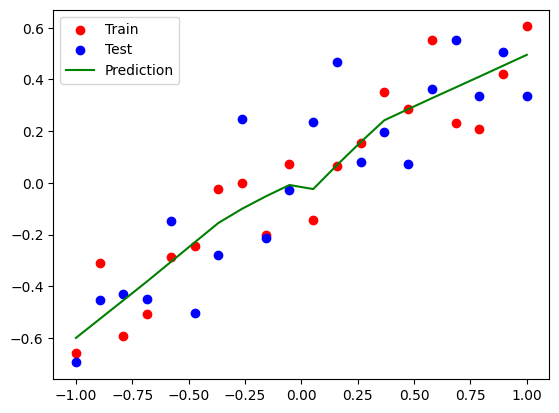

In [12]:
plt.scatter(x_train, y_train, c = "Red", label = "Train")
plt.scatter(x_test, y_test, c= "Blue", label = "Test")
plt.plot(x_test, y_pred, color = "Green", label = "Prediction")
plt.legend()
plt.show()

In [13]:
model1 = Sequential()
model1.add(Dense(128, activation='relu', input_dim=1))
model1.add(Dropout(0.2))
model1.add(Dense(128, activation='relu'))
model1.add(Dropout(0.2))
model1.add(Dense(1, activation='linear'))

In [14]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model1.compile(optimizer='adam', loss='mean_squared_error')

In [16]:
history1 = model1.fit(x_train, y_train, epochs=100, validation_data = (x_test, y_test))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1560 - val_loss: 0.1321
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - loss: 0.1266 - val_loss: 0.1071
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0868 - val_loss: 0.0862
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0749 - val_loss: 0.0690
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0600 - val_loss: 0.0553
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0495 - val_loss: 0.0447
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0408 - val_loss: 0.0369
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0374 - val_loss: 0.0319
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0198 - val_loss: 0.0293
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0228 - val_loss: 0.0287
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0303 - val_loss: 0.0294
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0167 -

In [17]:
y_pred1 = model1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


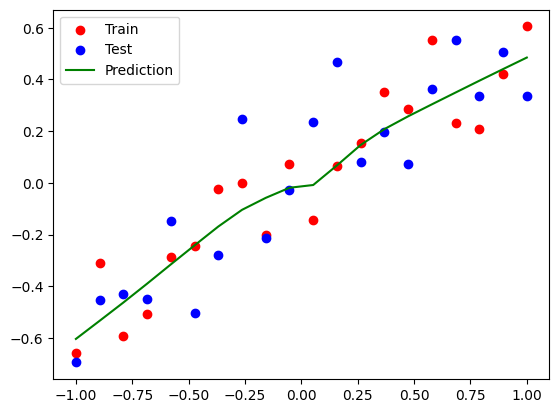

In [18]:
plt.scatter(x_train, y_train, c = "Red", label = "Train")
plt.scatter(x_test, y_test, c= "Blue", label = "Test")
plt.plot(x_test, y_pred1, color = "Green", label = "Prediction")
plt.legend()
plt.show()